In [1]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt

# Load the prepared time series
ts = pd.read_csv('data/processed/daily_sales_timeseries.csv')
ts.columns = ['ds', 'y']
ts['ds'] = pd.to_datetime(ts['ds'])

print(f"Loaded {len(ts)} days")
print(ts.head())

# Split into train/test - last 30 days for testing, rest for training
train = ts.iloc[:-30]
test = ts.iloc[-30:]

print(f"\nTrain size: {len(train)} days")
print(f"Test size: {len(test)} days")
print(f"Train range: {train['ds'].min()} to {train['ds'].max()}")
print(f"Test range: {test['ds'].min()} to {test['ds'].max()}")

c:\Users\HARSHAVARDHAN\Desktop\retailpulse-analytics\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


Loaded 739 days
          ds         y
0 2009-12-01  54513.50
1 2009-12-02  63352.51
2 2009-12-03  74037.91
3 2009-12-04  40732.92
4 2009-12-05   9803.05

Train size: 709 days
Test size: 30 days
Train range: 2009-12-01 00:00:00 to 2011-11-09 00:00:00
Test range: 2011-11-10 00:00:00 to 2011-12-09 00:00:00


In [2]:
# Fit Prophet on training data
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)
model.fit(train)

# Create future dataframe for the next 30 days (matching our test period)
future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

print("Forecast columns:", forecast.columns.tolist())
print("\nLast 5 forecasted rows:")
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())

Yearly seasonality is enabled with less than 730 days (approximately 2 years) of history. The model may be under-identified, and the trend/seasonality decomposition can be unstable and dependent on the Prophet/Stan version. Consider disabling yearly seasonality or providing more history.
09:33:01 - cmdstanpy - INFO - Chain [1] start processing
09:33:01 - cmdstanpy - INFO - Chain [1] done processing


Forecast columns: ['ds', 'trend', 'yhat_lower', 'yhat_upper', 'trend_lower', 'trend_upper', 'additive_terms', 'additive_terms_lower', 'additive_terms_upper', 'weekly', 'weekly_lower', 'weekly_upper', 'yearly', 'yearly_lower', 'yearly_upper', 'multiplicative_terms', 'multiplicative_terms_lower', 'multiplicative_terms_upper', 'yhat']

Last 5 forecasted rows:
            ds          yhat    yhat_lower    yhat_upper
734 2011-12-05  69049.311507  52315.189931  85316.253866
735 2011-12-06  73019.595804  55191.575856  90361.132547
736 2011-12-07  65499.369813  46432.974486  83478.860859
737 2011-12-08  70805.576127  52987.085531  88368.582592
738 2011-12-09  58524.110921  41646.786739  75115.181443


In [3]:
import numpy as np

# Merge forecast with actual test values
forecast_test = forecast[['ds', 'yhat']].merge(test, on='ds', how='inner')
forecast_test.columns = ['ds', 'yhat', 'actual']

print(forecast_test.head(10))

# Calculate MAPE (Mean Absolute Percentage Error)
# Exclude zero-sales days (Saturdays) since MAPE is undefined/infinite when actual=0
non_zero = forecast_test[forecast_test['actual'] > 0].copy()
non_zero['abs_pct_error'] = np.abs((non_zero['actual'] - non_zero['yhat']) / non_zero['actual'])
mape = non_zero['abs_pct_error'].mean() * 100

print(f"\nMAPE (excluding zero-sales days): {mape:.2f}%")
print(f"Target: ≤12% (per project requirements)")

if mape <= 12:
    print("✅ Model meets target accuracy!")
else:
    print(f"⚠️ Model is {mape - 12:.2f} percentage points above target — needs improvement")

          ds          yhat     actual
0 2011-11-10  59170.698892   71008.26
1 2011-11-11  49487.631099   55257.17
2 2011-11-12  20824.608359       0.00
3 2011-11-13  38504.867298   34069.92
4 2011-11-14  55068.206277  114419.89
5 2011-11-15  61046.174743   60807.29
6 2011-11-16  55928.343737   65958.17
7 2011-11-17  64023.623793   61103.13
8 2011-11-18  54900.097252   51275.39
9 2011-11-19  26806.233757       0.00

MAPE (excluding zero-sales days): 30.76%
Target: ≤12% (per project requirements)
⚠️ Model is 18.76 percentage points above target — needs improvement


In [5]:
# Re-prepare data with log transform
train_log = train.copy()
train_log['y'] = np.log1p(train_log['y'])

# Fit new model with UK holidays included
model2 = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.05  # default; controls trend flexibility
)
model2.add_country_holidays(country_name='UK')
model2.fit(train_log)

future2 = model2.make_future_dataframe(periods=30)
forecast2 = model2.predict(future2)

# Reverse the log transform to get back to actual sales scale
forecast2['yhat_original'] = np.expm1(forecast2['yhat'])

# Recalculate MAPE
forecast2_test = forecast2[['ds', 'yhat_original']].merge(test, on='ds', how='inner')
forecast2_test.columns = ['ds', 'yhat', 'actual']

non_zero2 = forecast2_test[forecast2_test['actual'] > 0].copy()
non_zero2['abs_pct_error'] = np.abs((non_zero2['actual'] - non_zero2['yhat']) / non_zero2['actual'])
mape2 = non_zero2['abs_pct_error'].mean() * 100

print(f"MAPE with log-transform + holidays: {mape2:.2f}%")
print(f"Previous MAPE (baseline): 30.76%")
print(f"Improvement: {30.76 - mape2:.2f} percentage points")

Yearly seasonality is enabled with less than 730 days (approximately 2 years) of history. The model may be under-identified, and the trend/seasonality decomposition can be unstable and dependent on the Prophet/Stan version. Consider disabling yearly seasonality or providing more history.
09:34:59 - cmdstanpy - INFO - Chain [1] start processing
09:34:59 - cmdstanpy - INFO - Chain [1] done processing


MAPE with log-transform + holidays: 98.00%
Previous MAPE (baseline): 30.76%
Improvement: -67.24 percentage points


In [6]:
print(forecast2_test.head(15))
print("\n--- Check for anything unusual ---")
print("Any negative yhat values:", (forecast2_test['yhat'] < 0).sum())
print("Yhat min/max:", forecast2_test['yhat'].min(), forecast2_test['yhat'].max())
print("Actual min/max:", forecast2_test['actual'].min(), forecast2_test['actual'].max())

           ds          yhat     actual
0  2011-11-10  36816.088814   71008.26
1  2011-11-11  24006.675722   55257.17
2  2011-11-12      0.347854       0.00
3  2011-11-13  10309.826655   34069.92
4  2011-11-14  21065.807326  114419.89
5  2011-11-15  33653.614208   60807.29
6  2011-11-16  27773.177986   65958.17
7  2011-11-17  32209.387555   61103.13
8  2011-11-18  23965.101018   51275.39
9  2011-11-19      0.549194       0.00
10 2011-11-20  13714.564347   35058.57
11 2011-11-21  32463.326391   49805.72
12 2011-11-22  59876.933052   64089.82
13 2011-11-23  56604.581126   80104.18
14 2011-11-24  74276.107485   50978.63

--- Check for anything unusual ---
Any negative yhat values: 0
Yhat min/max: 0.34785375033931837 238551.96994373432
Actual min/max: 0.0 200938.6


In [7]:
# Fit model with holidays but WITHOUT log transform
model3 = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.05
)
model3.add_country_holidays(country_name='UK')
model3.fit(train)  # note: using original 'train', not train_log

future3 = model3.make_future_dataframe(periods=30)
forecast3 = model3.predict(future3)

forecast3_test = forecast3[['ds', 'yhat']].merge(test, on='ds', how='inner')
forecast3_test.columns = ['ds', 'yhat', 'actual']

non_zero3 = forecast3_test[forecast3_test['actual'] > 0].copy()
non_zero3['abs_pct_error'] = np.abs((non_zero3['actual'] - non_zero3['yhat']) / non_zero3['actual'])
mape3 = non_zero3['abs_pct_error'].mean() * 100

print(f"MAPE with holidays only (no log transform): {mape3:.2f}%")
print(f"Original baseline MAPE: 30.76%")

Yearly seasonality is enabled with less than 730 days (approximately 2 years) of history. The model may be under-identified, and the trend/seasonality decomposition can be unstable and dependent on the Prophet/Stan version. Consider disabling yearly seasonality or providing more history.
09:36:04 - cmdstanpy - INFO - Chain [1] start processing
09:36:04 - cmdstanpy - INFO - Chain [1] done processing


MAPE with holidays only (no log transform): 30.92%
Original baseline MAPE: 30.76%


In [9]:
# Check how extreme the outliers really are
print("Training data percentiles:")
print(train['y'].describe())
print(f"\n99th percentile: {train['y'].quantile(0.99):.2f}")
print(f"95th percentile: {train['y'].quantile(0.95):.2f}")

# Cap at 95th percentile
cap_value = train['y'].quantile(0.95)
train_capped = train.copy()
train_capped['y'] = train_capped['y'].clip(upper=cap_value)

print(f"\nRows affected by capping: {(train['y'] > cap_value).sum()} out of {len(train)}")

# Fit model on capped data
model4 = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)
model4.fit(train_capped)

future4 = model4.make_future_dataframe(periods=30)
forecast4 = model4.predict(future4)

forecast4_test = forecast4[['ds', 'yhat']].merge(test, on='ds', how='inner')
forecast4_test.columns = ['ds', 'yhat', 'actual']

non_zero4 = forecast4_test[forecast4_test['actual'] > 0].copy()
non_zero4['abs_pct_error'] =np.abs((non_zero4['actual'] - non_zero4['yhat']) / non_zero4['actual'])
mape4 = non_zero4['abs_pct_error'].mean() * 100

print(f"\nMAPE with 95th-percentile capped training data: {mape4:.2f}%")
print(f"Original baseline: 30.76%")

Yearly seasonality is enabled with less than 730 days (approximately 2 years) of history. The model may be under-identified, and the trend/seasonality decomposition can be unstable and dependent on the Prophet/Stan version. Consider disabling yearly seasonality or providing more history.


Training data percentiles:
count       709.000000
mean      27191.150717
std       21738.041963
min           0.000000
25%       14147.140000
50%       25667.510000
75%       36814.820000
max      199236.400000
Name: y, dtype: float64

99th percentile: 95939.55
95th percentile: 63302.16

Rows affected by capping: 36 out of 709


09:37:10 - cmdstanpy - INFO - Chain [1] start processing
09:37:10 - cmdstanpy - INFO - Chain [1] done processing



MAPE with 95th-percentile capped training data: 24.06%
Original baseline: 30.76%


In [10]:
# Try 90th percentile cap (more aggressive) + adjust trend flexibility
cap_value_90 = train['y'].quantile(0.90)
train_capped_90 = train.copy()
train_capped_90['y'] = train_capped_90['y'].clip(upper=cap_value_90)

print(f"90th percentile cap: {cap_value_90:.2f}")
print(f"Rows affected: {(train['y'] > cap_value_90).sum()} out of {len(train)}")

model5 = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.1  # slightly more flexible trend
)
model5.fit(train_capped_90)

future5 = model5.make_future_dataframe(periods=30)
forecast5 = model5.predict(future5)

forecast5_test = forecast5[['ds', 'yhat']].merge(test, on='ds', how='inner')
forecast5_test.columns = ['ds', 'yhat', 'actual']

non_zero5 = forecast5_test[forecast5_test['actual'] > 0].copy()
non_zero5['abs_pct_error'] = np.abs((non_zero5['actual'] - non_zero5['yhat']) / non_zero5['actual'])
mape5 = non_zero5['abs_pct_error'].mean() * 100

print(f"\nMAPE with 90th percentile cap + flexible trend: {mape5:.2f}%")
print(f"Previous best (95th percentile): 24.06%")

Yearly seasonality is enabled with less than 730 days (approximately 2 years) of history. The model may be under-identified, and the trend/seasonality decomposition can be unstable and dependent on the Prophet/Stan version. Consider disabling yearly seasonality or providing more history.


90th percentile cap: 52616.80
Rows affected: 71 out of 709


09:37:37 - cmdstanpy - INFO - Chain [1] start processing
09:37:37 - cmdstanpy - INFO - Chain [1] done processing



MAPE with 90th percentile cap + flexible trend: 27.15%
Previous best (95th percentile): 24.06%


Final baseline Prophet MAPE: 24.06%
Target: ≤12%
Gap: 12.06 percentage points — to be addressed via LSTM ensemble (Day 8) and tuning (Day 11)

✅ Saved prophet_baseline.pkl and prophet_forecast.csv


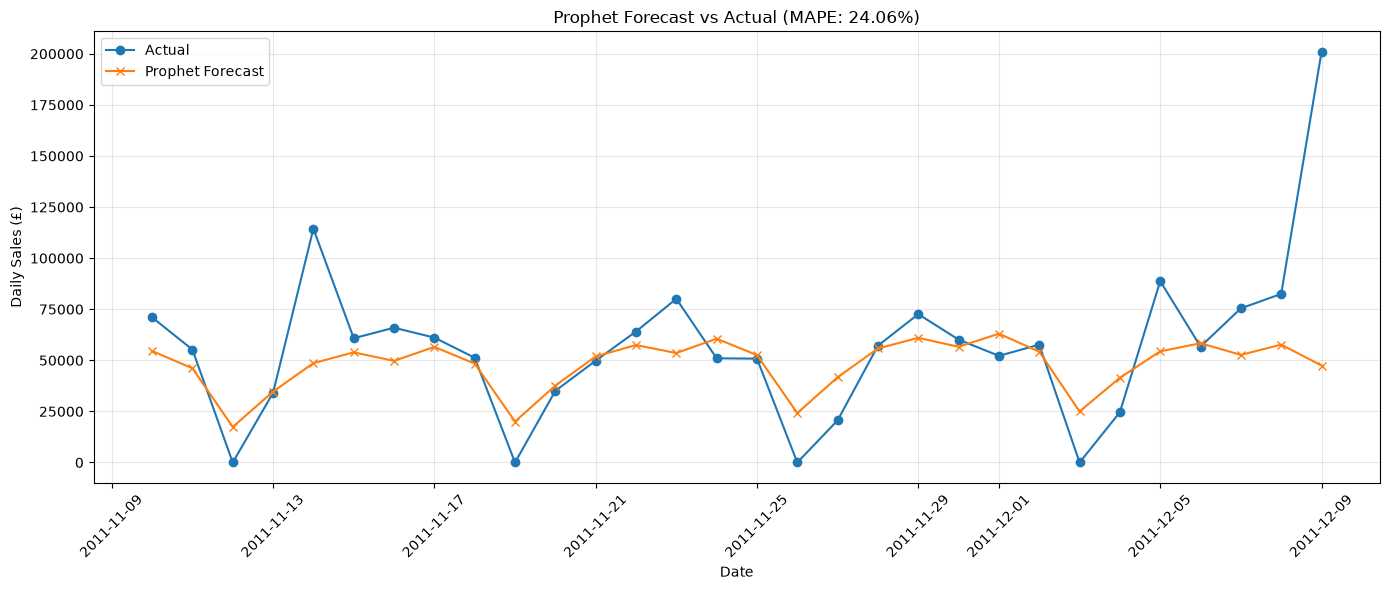

✅ Saved forecast comparison chart


In [11]:
# Confirm model4 (95th percentile cap) is your best baseline
print(f"Final baseline Prophet MAPE: 24.06%")
print(f"Target: ≤12%")
print(f"Gap: {24.06 - 12:.2f} percentage points — to be addressed via LSTM ensemble (Day 8) and tuning (Day 11)")

# Save the model and forecast for later use
import joblib
joblib.dump(model4, 'models/prophet_baseline.pkl')

forecast4.to_csv('data/processed/prophet_forecast.csv', index=False)
print("\n✅ Saved prophet_baseline.pkl and prophet_forecast.csv")

# Visualize the forecast vs actual
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(test['ds'], test['y'], label='Actual', marker='o')
ax.plot(forecast4_test['ds'], forecast4_test['yhat'], label='Prophet Forecast', marker='x')
ax.set_title(f'Prophet Forecast vs Actual (MAPE: 24.06%)')
ax.set_xlabel('Date')
ax.set_ylabel('Daily Sales (£)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('docs/prophet_forecast_vs_actual.png', dpi=100, bbox_inches='tight')
plt.show()

print("✅ Saved forecast comparison chart")

In [ ]:
import mlflow

mlflow.set_experiment("RetailPulse_Demand_Forecasting")

with mlflow.start_run(run_name="prophet_baseline_95pct_cap"):
    mlflow.log_param("model_type", "Prophet")
    mlflow.log_param("outlier_cap_percentile", 95)
    mlflow.log_param("yearly_seasonality", True)
    mlflow.log_param("weekly_seasonality", True)
    mlflow.log_metric("MAPE", 24.06)
    mlflow.log_artifact('docs/prophet_forecast_vs_actual.png')
    print("✅ Logged to MLflow")